Loading California Housing Dataset...

First 5 Rows of Dataset:

   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  Price  
0    -122.23  4.526  
1    -122.22  3.585  
2    -122.24  3.521  
3    -122.25  3.413  
4    -122.25  3.422  

Dataset Information

<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   MedInc      20640 non-null  float64
 1   HouseAge    20640 non-null  float64
 2   AveRooms    20640 non-null  float64
 3   AveBedrms   20640

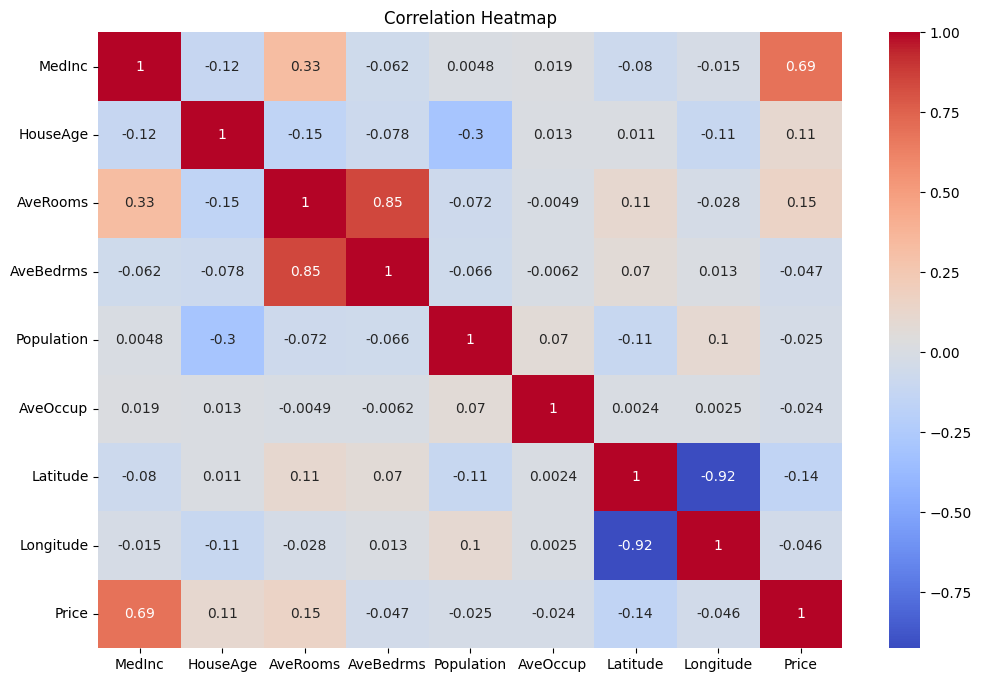

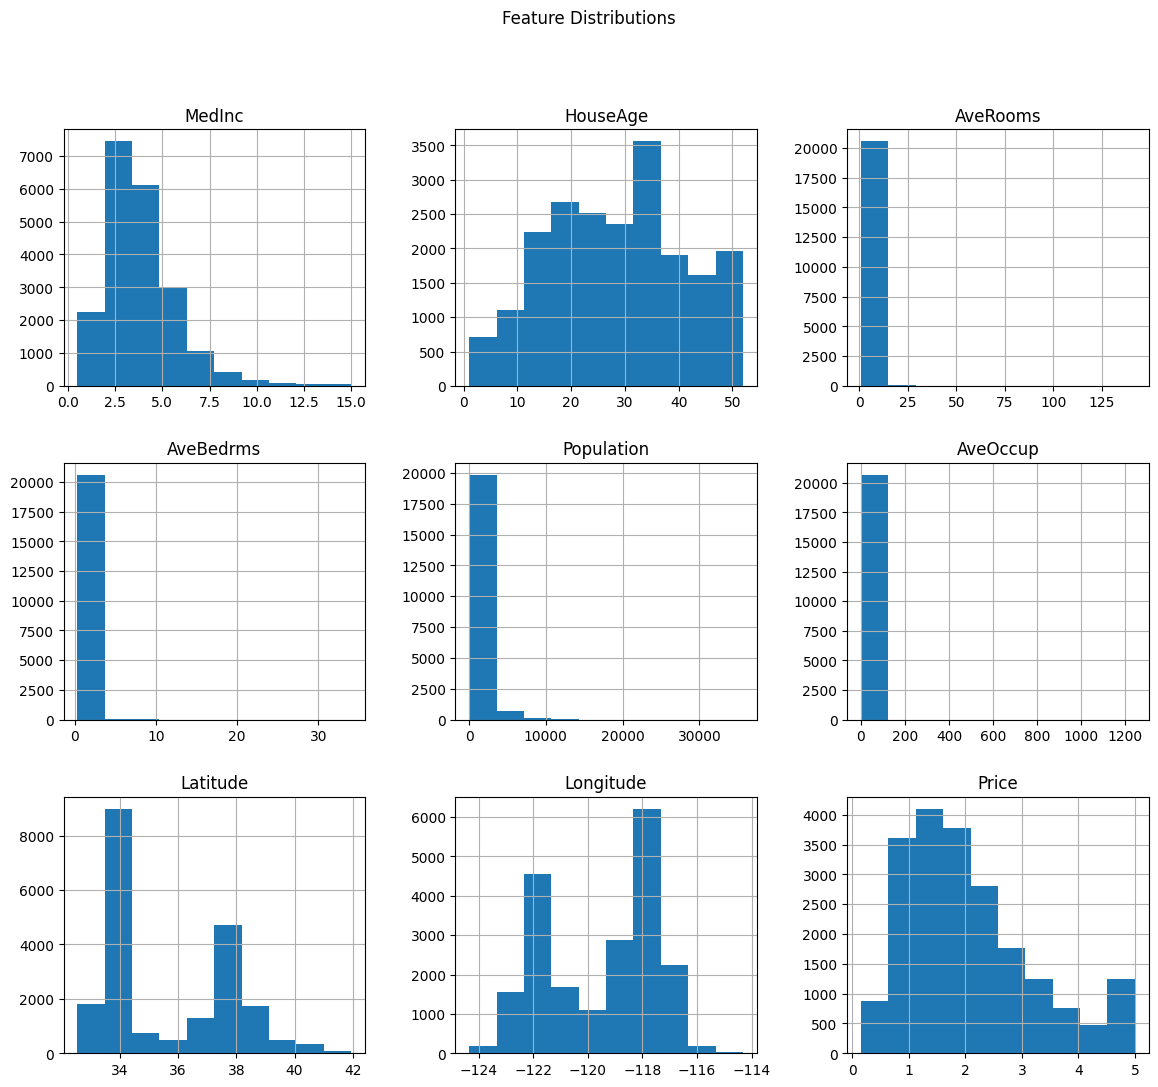


Training Data Shape: (16512, 8)
Testing Data Shape: (4128, 8)

Model Trained Successfully!

Model Coefficients

      Feature  Coefficient
0      MedInc     0.448675
1    HouseAge     0.009724
2    AveRooms    -0.123323
3   AveBedrms     0.783145
4  Population    -0.000002
5    AveOccup    -0.003526
6    Latitude    -0.419792
7   Longitude    -0.433708

Model Evaluation

Mean Absolute Error (MAE): 0.5332
Root Mean Squared Error (RMSE): 0.7456
R2 Score: 0.5758


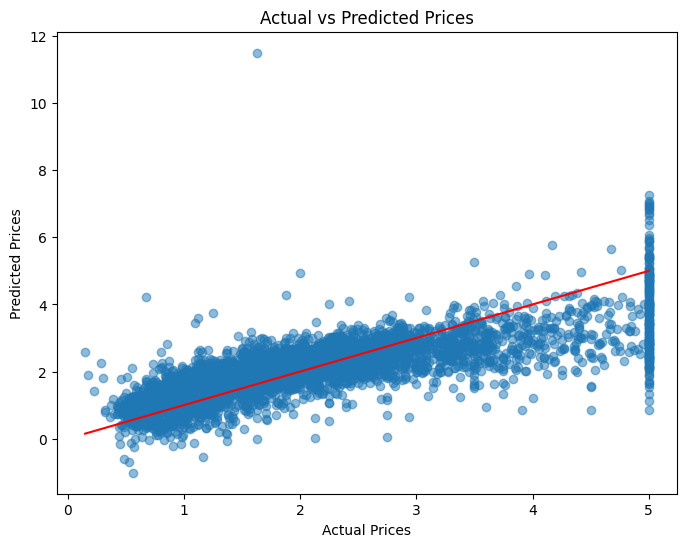

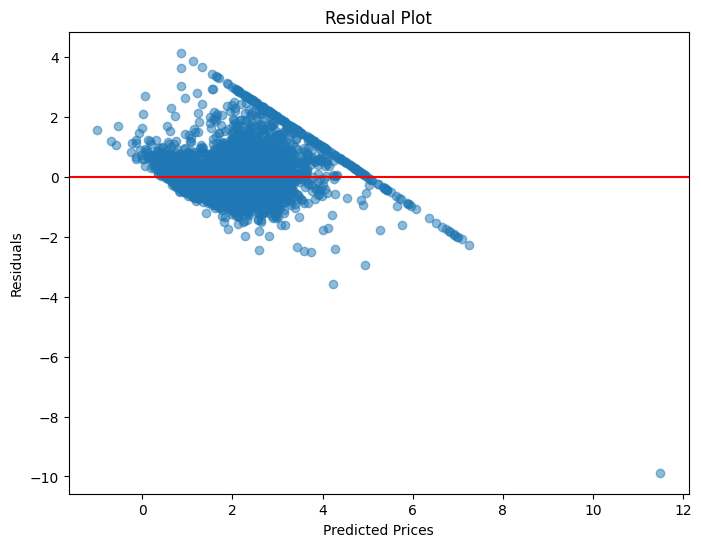


Model Saved Successfully!

Sample Prediction

Predicted House Price: 0.7191228416019015

Task Completed Successfully!


In [2]:
# ==========================================
# AI & ML Task 1
# Linear Regression - California Housing Dataset
# ==========================================

# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

# ==========================================
# Load Dataset
# ==========================================

print("Loading California Housing Dataset...\n")

housing = fetch_california_housing(as_frame=True)

# Create DataFrame
df = pd.concat(
    [housing.data, housing.target.rename("Price")],
    axis=1
)

# Display first 5 rows
print("First 5 Rows of Dataset:\n")
print(df.head())

# ==========================================
# Dataset Information
# ==========================================

print("\n==========================================")
print("Dataset Information")
print("==========================================\n")

print(df.info())

# ==========================================
# Check Missing Values
# ==========================================

print("\n==========================================")
print("Missing Values")
print("==========================================\n")

print(df.isnull().sum())

# ==========================================
# Statistical Summary
# ==========================================

print("\n==========================================")
print("Statistical Summary")
print("==========================================\n")

print(df.describe())

# ==========================================
# Correlation Heatmap
# ==========================================

plt.figure(figsize=(12, 8))

sns.heatmap(
    df.corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Heatmap")

plt.show()

# ==========================================
# Histograms
# ==========================================

df.hist(figsize=(14, 12))

plt.suptitle("Feature Distributions")

plt.show()

# ==========================================
# Define Features and Target
# ==========================================

X = df.drop("Price", axis=1)

y = df["Price"]

# ==========================================
# Train-Test Split
# ==========================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("\nTraining Data Shape:", X_train.shape)
print("Testing Data Shape:", X_test.shape)

# ==========================================
# Train Linear Regression Model
# ==========================================

model = LinearRegression()

model.fit(X_train, y_train)

print("\nModel Trained Successfully!")

# ==========================================
# Model Coefficients
# ==========================================

coeff_df = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_
})

print("\n==========================================")
print("Model Coefficients")
print("==========================================\n")

print(coeff_df)

# ==========================================
# Predictions
# ==========================================

y_pred = model.predict(X_test)

# ==========================================
# Evaluation Metrics
# ==========================================

mae = mean_absolute_error(y_test, y_pred)

mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)

r2 = r2_score(y_test, y_pred)

print("\n==========================================")
print("Model Evaluation")
print("==========================================\n")

print(f"Mean Absolute Error (MAE): {mae:.4f}")

print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")

print(f"R2 Score: {r2:.4f}")

# ==========================================
# Actual vs Predicted Plot
# ==========================================

plt.figure(figsize=(8, 6))

plt.scatter(
    y_test,
    y_pred,
    alpha=0.5
)

plt.xlabel("Actual Prices")

plt.ylabel("Predicted Prices")

plt.title("Actual vs Predicted Prices")

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color='red'
)

plt.show()

# ==========================================
# Residual Plot
# ==========================================

residuals = y_test - y_pred

plt.figure(figsize=(8, 6))

plt.scatter(
    y_pred,
    residuals,
    alpha=0.5
)

plt.axhline(
    y=0,
    color='red'
)

plt.xlabel("Predicted Prices")

plt.ylabel("Residuals")

plt.title("Residual Plot")

plt.show()

# ==========================================
# Save Model
# ==========================================

with open("linear_regression_model.pkl", "wb") as file:
    pickle.dump(model, file)

print("\nModel Saved Successfully!")

# ==========================================
# Sample Prediction
# ==========================================

sample_data = X_test.iloc[0:1]

sample_prediction = model.predict(sample_data)

print("\n==========================================")
print("Sample Prediction")
print("==========================================\n")

print("Predicted House Price:", sample_prediction[0])

print("\nTask Completed Successfully!")